In [ ]:
!pip install transformers torch torchvision tqdm scikit-learn

In [3]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from pathlib import Path
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CSV_PATH = "/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/metadata.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/embeddings")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(CSV_PATH)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

embeddings = []
meta_rows = []

with torch.no_grad():
    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Embedding images",
        ncols=100,
        smoothing=0.05
    ):
        img_path = Path(row["image_path"])
        if not img_path.exists():
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            inputs = processor(images=img, return_tensors="pt").to(DEVICE)

            feat = model.get_image_features(**inputs)
            feat = feat / feat.norm(dim=-1, keepdim=True)

            embeddings.append(feat.cpu().numpy()[0])
            meta_rows.append(row.values)

        except:
            continue

embeddings = np.asarray(embeddings, dtype=np.float32)
meta = pd.DataFrame(meta_rows, columns=df.columns)

np.save(OUTPUT_DIR / "clip_embeddings.npy", embeddings)
meta.to_csv(OUTPUT_DIR / "clip_embeddings_meta.csv", index=False)

100%|██████████| 24980/24980 [4:13:09<00:00,  1.64it/s]


In [9]:
embeddings

array([[-0.02612679, -0.03244119, -0.01186191, ...,  0.03094364,
        -0.01946553, -0.01029146],
       [-0.03234066, -0.03211685, -0.01071963, ...,  0.02524923,
        -0.01797878, -0.01395559],
       [-0.0263571 , -0.02840252,  0.00455737, ...,  0.0424981 ,
        -0.01103817, -0.02646485],
       ...,
       [ 0.04275552, -0.00198482, -0.02820327, ..., -0.00229161,
         0.00149561, -0.0499884 ],
       [ 0.03742962,  0.00063823, -0.0229437 , ...,  0.00864211,
         0.01519709, -0.05162241],
       [ 0.03983024, -0.02152429, -0.04050014, ...,  0.03748066,
         0.00484887, -0.03236781]], dtype=float32)

In [6]:
from tqdm import tqdm
from collections import defaultdict

def original_to_duplicates(data):
    first_seen = {}                  # row -> original index
    duplicates_map = defaultdict(list)  # original index -> duplicate indices

    for idx, row in tqdm(enumerate(data), total=len(data), desc="Scanning rows"):
        row_key = tuple(row)  # make hashable

        if row_key in first_seen:
            original_idx = first_seen[row_key]
            duplicates_map[original_idx].append(idx)
        else:
            first_seen[row_key] = idx

    return dict(duplicates_map)


In [11]:
embeddings = np.load("/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/embeddings/clip_embeddings.npy")
dup = original_to_duplicates(embeddings)
print(dup)

Scanning rows: 100%|██████████| 30000/30000 [00:03<00:00, 8700.93it/s]


{}


In [17]:
metadata = pd.read_csv("/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/embeddings/clip_embeddings_meta.csv")
metadata.head()
paths = metadata["image_path"].values

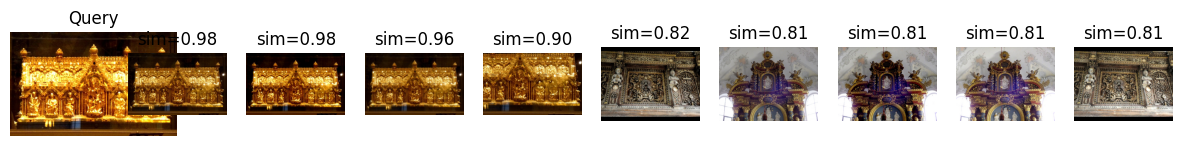

In [18]:
import random

idx = random.randint(0, len(embeddings)-1)
query = embeddings[idx].reshape(1, -1) # (512,) to (1, 512) for cosine similarity
sims = cosine_similarity(query, embeddings)[0] # similarity between query and all images
top_k = sims.argsort()[-10:][::-1] # uses the similarity score to get most images similar to the query

plt.figure(figsize=(15,3))

qimg = Image.open(paths[idx])
plt.subplot(1, 6, 1)
plt.imshow(qimg)
plt.axis('off')
plt.title("Query")

for i, j in enumerate(top_k[1:]):
    img = Image.open(paths[j])
    plt.subplot(1, 10, i+2)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"sim={sims[j]:.2f}")

plt.show()